<a href="https://colab.research.google.com/github/poudelsagar725/ANG-CAL/blob/main/ONELASTDANCE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Loading and Initial Exploration**

In [ ]:
!pip install shap lime

In [ ]:
# importing required libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score

from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, roc_curve, auc)
from sklearn.preprocessing import label_binarize

import shap

from lime.lime_tabular import LimeTabularExplainer

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# load the dataset from the csv file
sleep_disorder_data = pd.read_csv("/content/sample_data/Sleep_Data.csv")

# replace nan values in the sleep disorder column with no sleep disorder
# nan in this dataset explicitly represents individuals with no sleep disorder
sleep_disorder_data["Sleep Disorder"] = sleep_disorder_data["Sleep Disorder"].fillna("No Sleep Disorder")

# display the first 5 rows to confirm the fix
print("\nFirst 5 Rows:")
sleep_disorder_data.head()


First 5 Rows:


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,35,Doctor,6.65,7,50,7,Normal Weight,120/80,71,7100,Healthy
1,2,Male,42,Teacher,6.90,8,52,4,Normal,135/90,66,7000,Healthy
2,3,Male,34,Software Engineer,6.95,7,66,6,Overweight,126/83,74,6100,Healthy
3,4,Male,32,Doctor,6.90,6,52,7,Normal,120/80,71,6500,Healthy
4,5,Male,37,Lawyer,6.85,7,60,6,Normal,125/80,71,6500,Healthy


In [ ]:
# columns in the data
sleep_disorder_data.columns

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder'],
      dtype='object')

In [ ]:
# check the shape of the dataset
# this returns a tuple of (number of rows, number of columns)
shape = sleep_disorder_data.shape
print("Dataset Shape:", shape)
print("Number of Records:", shape[0])
print("Number of Features:", shape[1])

Dataset Shape: (15000, 13)
Number of Records: 15000
Number of Features: 13


In [ ]:
# display basic descriptive statistics for all numerical columns
# this includes count, mean, standard deviation, min, max, and quartiles
print("\nDescriptive Statistics:")
sleep_disorder_data.describe()


Descriptive Statistics:


,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7500.500000,44.130667,6.997327,7.131267,59.925000,5.654800,70.857533,6795.080000
std,4330.271354,6.840091,0.615187,1.053111,16.814374,1.393568,3.614836,1329.706484
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,3750.750000,40.000000,6.500000,6.000000,45.000000,4.000000,68.000000,6000.000000
50%,7500.500000,44.000000,7.000000,7.000000,60.000000,6.000000,70.000000,6500.000000
75%,11250.250000,48.000000,7.450000,8.000000,75.000000,6.000000,72.000000,7600.000000
max,15000.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [ ]:
# display detailed information about the dataset
# this shows column names, non-null counts, and data types
# useful for identifying missing values and incorrect data types
print("\nDataset Information:")
sleep_disorder_data.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                15000 non-null  int64  
 1   Gender                   15000 non-null  object 
 2   Age                      15000 non-null  int64  
 3   Occupation               15000 non-null  object 
 4   Sleep Duration           15000 non-null  float64
 5   Quality of Sleep         15000 non-null  int64  
 6   Physical Activity Level  15000 non-null  int64  
 7   Stress Level             15000 non-null  int64  
 8   BMI Category             15000 non-null  object 
 9   Blood Pressure           15000 non-null  object 
 10  Heart Rate               15000 non-null  int64  
 11  Daily Steps              15000 non-null  int64  
 12  Sleep Disorder           15000 non-null  object 
dtypes: float64(1), int64(7), object(5)
memory usage: 1.5+ 

In [ ]:
# check the number of missing values in each column
# this gives a count of nulls per feature to guide preprocessing decisions
print("\nMissing Values Per Column:")
print(sleep_disorder_data.isnull().sum())


Missing Values Per Column:
Person ID                  0
Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Blood Pressure             0
Heart Rate                 0
Daily Steps                0
Sleep Disorder             0
dtype: int64


# **Exploartory Data Analysis**

In [ ]:
# set a consistent visual style across all plots
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)


# select only numerical columns for correlation and distribution analysis
numerical_cols = sleep_disorder_data.select_dtypes(include=["float64", "int64"]).columns.tolist()


# define a consistent color palette mapped to each sleep disorder class
disorder_palette = {
    "Healthy": "#55A868",
    "Insomnia":          "#C44E52",
    "Sleep Apnea":       "#4C72B0"
}

In [ ]:
# standardise all text in the Sleep Disorder column
# strip leading/trailing whitespace and convert to title case
# this ensures consistent formatting across all class labels
sleep_disorder_data["Sleep Disorder"] = sleep_disorder_data["Sleep Disorder"].str.strip().str.title()

# verify the correction by displaying the updated class distribution
print("Corrected Sleep Disorder Class Distribution:")
print(sleep_disorder_data["Sleep Disorder"].value_counts())

Corrected Sleep Disorder Class Distribution:
Sleep Disorder
Healthy        5000
Sleep Apnea    5000
Insomnia       5000
Name: count, dtype: int64


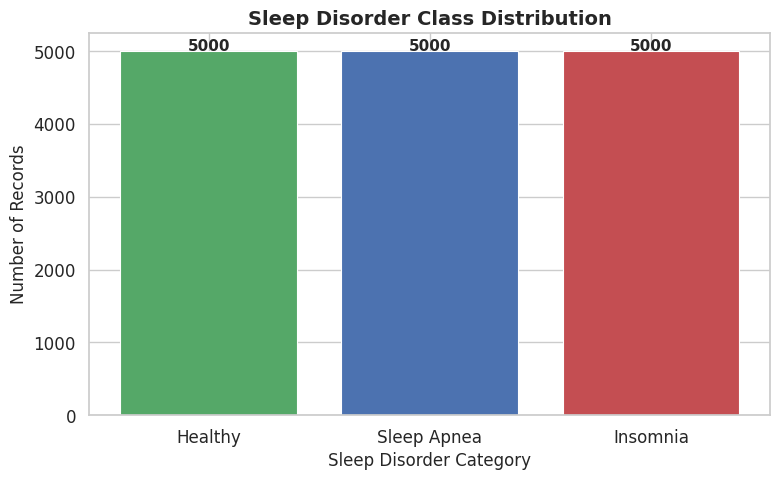

In [ ]:
# class distribution of sleep disorder (bar chart)
# shows how many records fall under each sleep disorder category
fig, ax = plt.subplots(figsize=(8, 5))
disorder_counts = sleep_disorder_data["Sleep Disorder"].value_counts()
bars = ax.bar(disorder_counts.index, disorder_counts.values,
              color=[disorder_palette[d] for d in disorder_counts.index],
              edgecolor="white", linewidth=0.8)
ax.set_title("Sleep Disorder Class Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Sleep Disorder Category", fontsize=12)
ax.set_ylabel("Number of Records", fontsize=12)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 3,
            str(int(bar.get_height())),
            ha="center", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

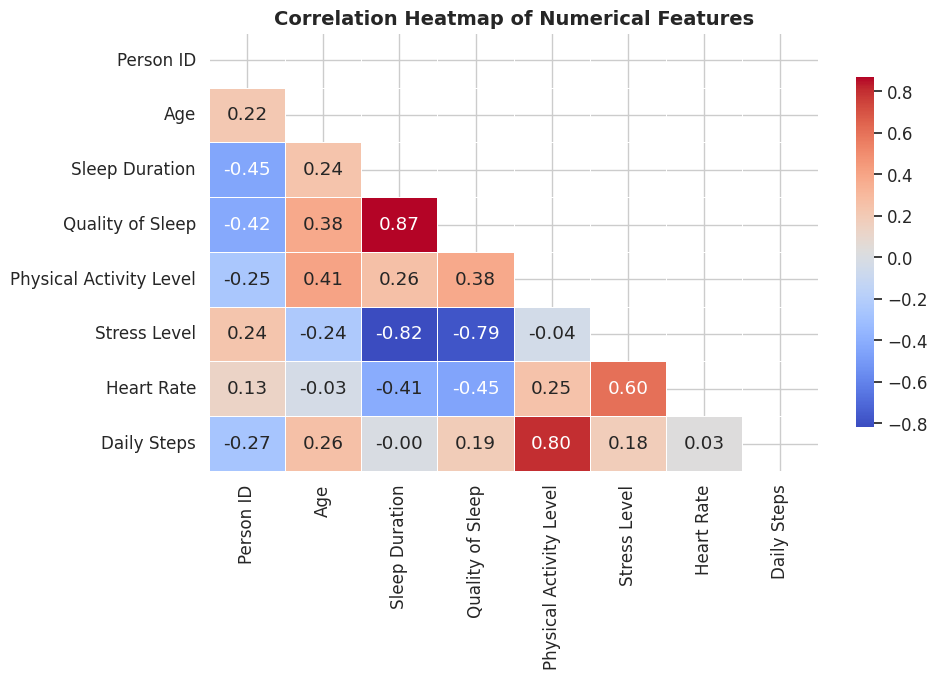

In [ ]:
# correlation heatmap of all numerical features
# reveals linear relationships between physiological and behavioural variables
fig, ax = plt.subplots(figsize=(10, 7))
correlation_matrix = sleep_disorder_data[numerical_cols].corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.5, linecolor="white",
            cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlation Heatmap of Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

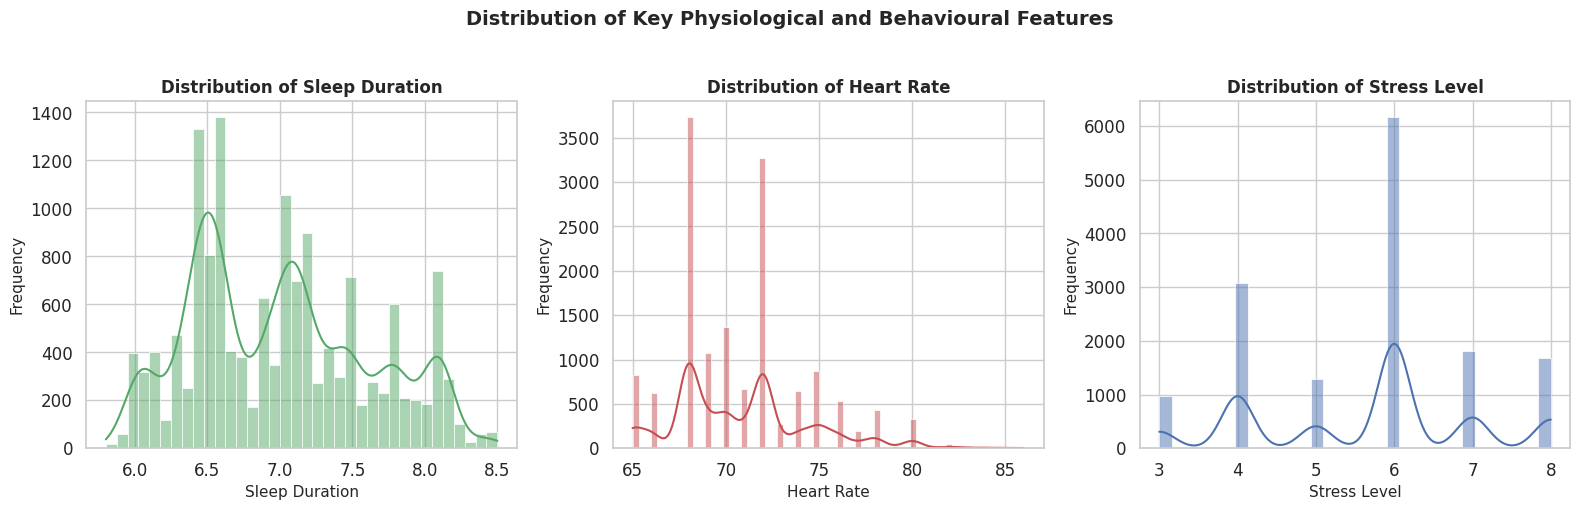

In [ ]:
# distribution of key features
# shows the spread and skewness of sleep duration, heart rate, and stress level
key_features = ["Sleep Duration", "Heart Rate", "Stress Level"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, feature in enumerate(key_features):
    sns.histplot(sleep_disorder_data[feature], kde=True,
                 color=list(disorder_palette.values())[i],
                 edgecolor="white", linewidth=0.5, ax=axes[i])
    axes[i].set_title(f"Distribution of {feature}", fontsize=12, fontweight="bold")
    axes[i].set_xlabel(feature, fontsize=11)
    axes[i].set_ylabel("Frequency", fontsize=11)
plt.suptitle("Distribution of Key Physiological and Behavioural Features",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

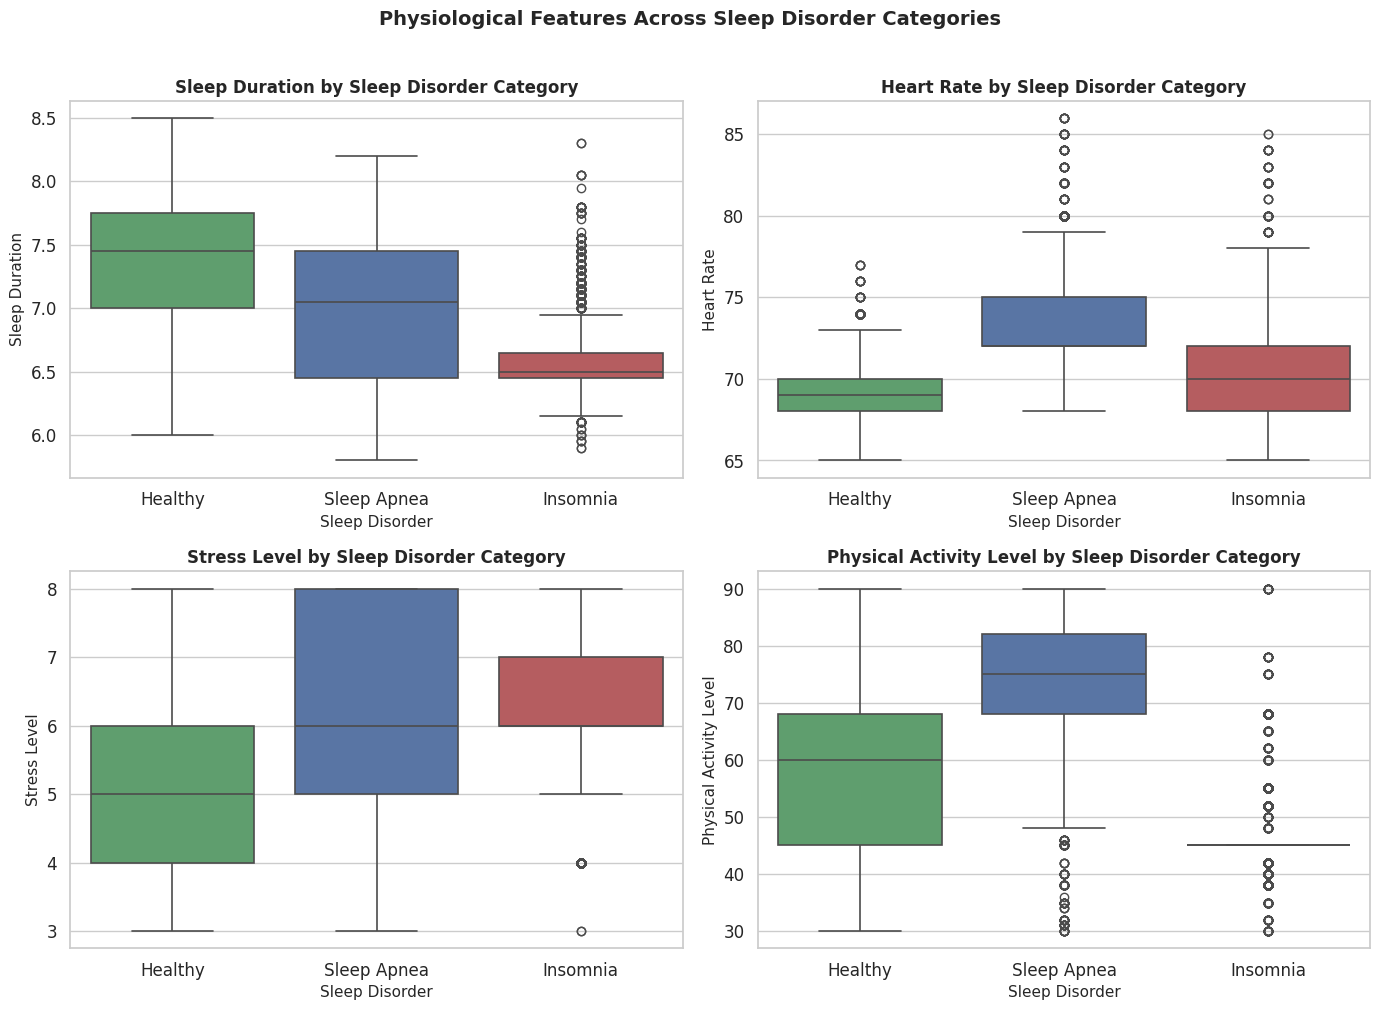

In [ ]:
# boxplots of physiological features against sleep disorder categories
# identifies how physiological values differ across disorder classes
physiological_features = ["Sleep Duration", "Heart Rate",
                           "Stress Level", "Physical Activity Level"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, feature in enumerate(physiological_features):
    sns.boxplot(data=sleep_disorder_data, x="Sleep Disorder", y=feature,
                palette=disorder_palette, linewidth=1.2, ax=axes[i])
    axes[i].set_title(f"{feature} by Sleep Disorder Category",
                      fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Sleep Disorder", fontsize=11)
    axes[i].set_ylabel(feature, fontsize=11)
plt.suptitle("Physiological Features Across Sleep Disorder Categories",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

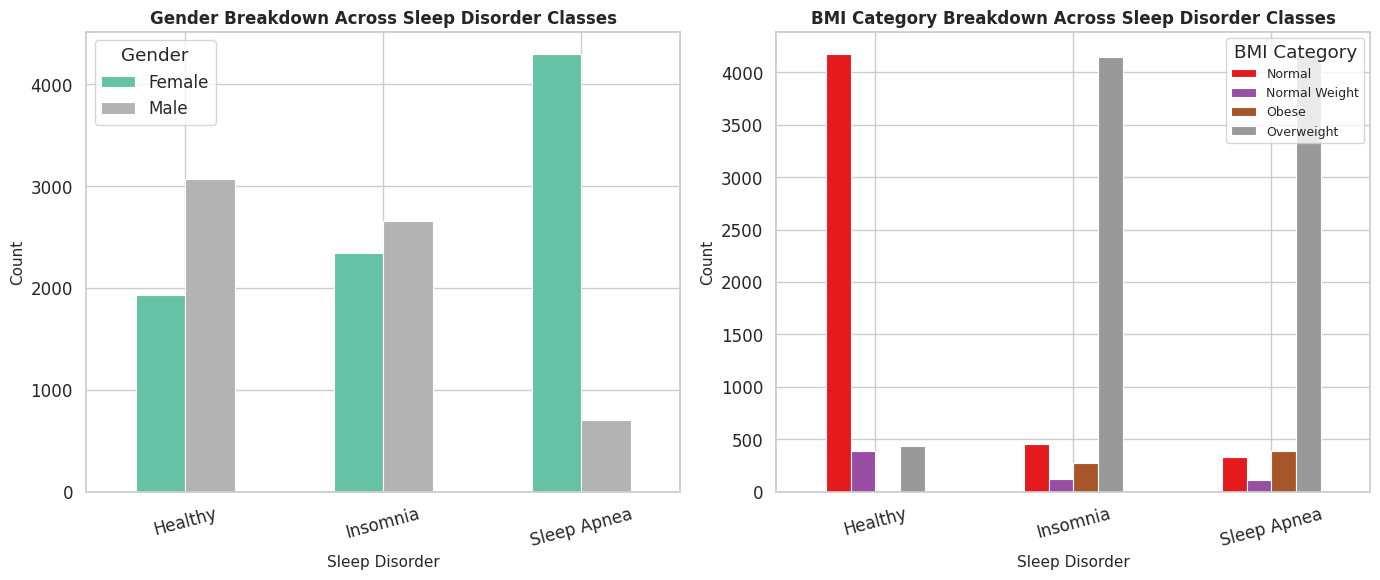

In [ ]:
# gender and bmi category breakdown across disorder classes
# reveals demographic patterns within each sleep disorder group
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
gender_disorder = sleep_disorder_data.groupby(
    ["Sleep Disorder", "Gender"]).size().unstack(fill_value=0)
gender_disorder.plot(kind="bar", ax=axes[0], colormap="Set2",
                     edgecolor="white", linewidth=0.8)
axes[0].set_title("Gender Breakdown Across Sleep Disorder Classes",
                  fontsize=12, fontweight="bold")
axes[0].set_xlabel("Sleep Disorder", fontsize=11)
axes[0].set_ylabel("Count", fontsize=11)
axes[0].tick_params(axis="x", rotation=15)
axes[0].legend(title="Gender")

bmi_disorder = sleep_disorder_data.groupby(
    ["Sleep Disorder", "BMI Category"]).size().unstack(fill_value=0)
bmi_disorder.plot(kind="bar", ax=axes[1], colormap="Set1",
                  edgecolor="white", linewidth=0.8)
axes[1].set_title("BMI Category Breakdown Across Sleep Disorder Classes",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("Sleep Disorder", fontsize=11)
axes[1].set_ylabel("Count", fontsize=11)
axes[1].tick_params(axis="x", rotation=15)
axes[1].legend(title="BMI Category", fontsize=9)
plt.tight_layout()
plt.show()

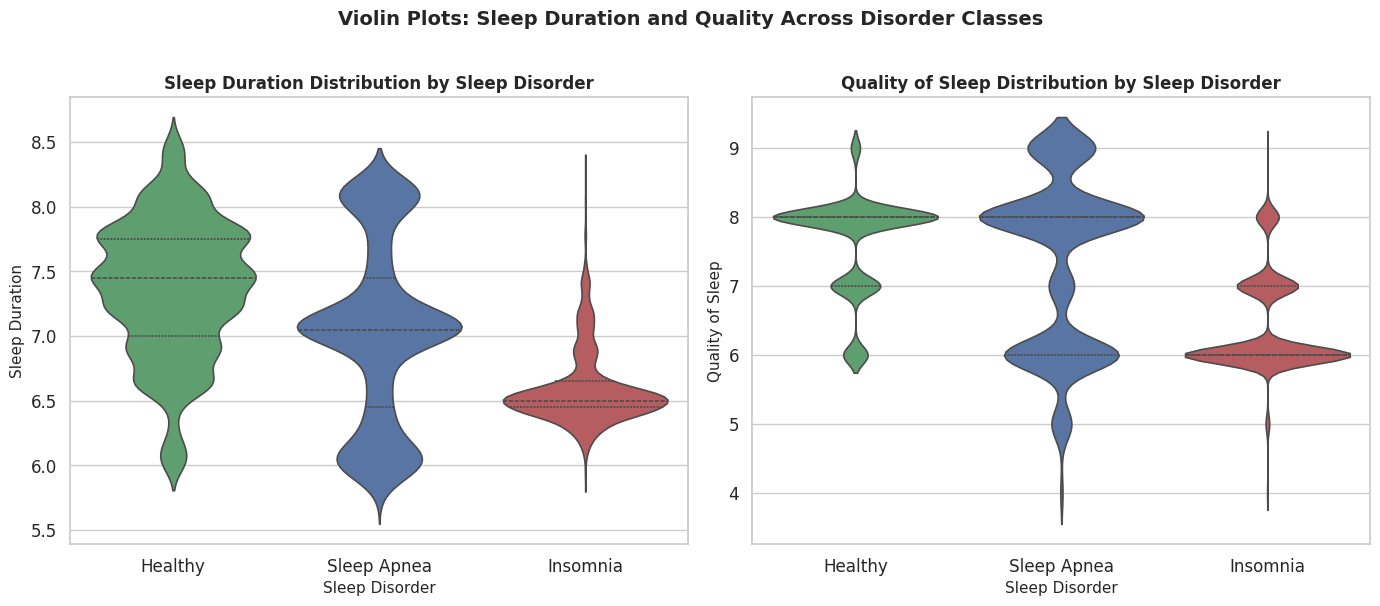

In [ ]:
# violin plot of sleep duration and quality of sleep by disorder class
# violin plots reveal the full distribution shape including density and spread
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, feature in zip(axes, ["Sleep Duration", "Quality of Sleep"]):
    sns.violinplot(data=sleep_disorder_data, x="Sleep Disorder", y=feature,
                   palette=disorder_palette, inner="quartile",
                   linewidth=1.2, ax=ax)
    ax.set_title(f"{feature} Distribution by Sleep Disorder",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Sleep Disorder", fontsize=11)
    ax.set_ylabel(feature, fontsize=11)
plt.suptitle("Violin Plots: Sleep Duration and Quality Across Disorder Classes",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

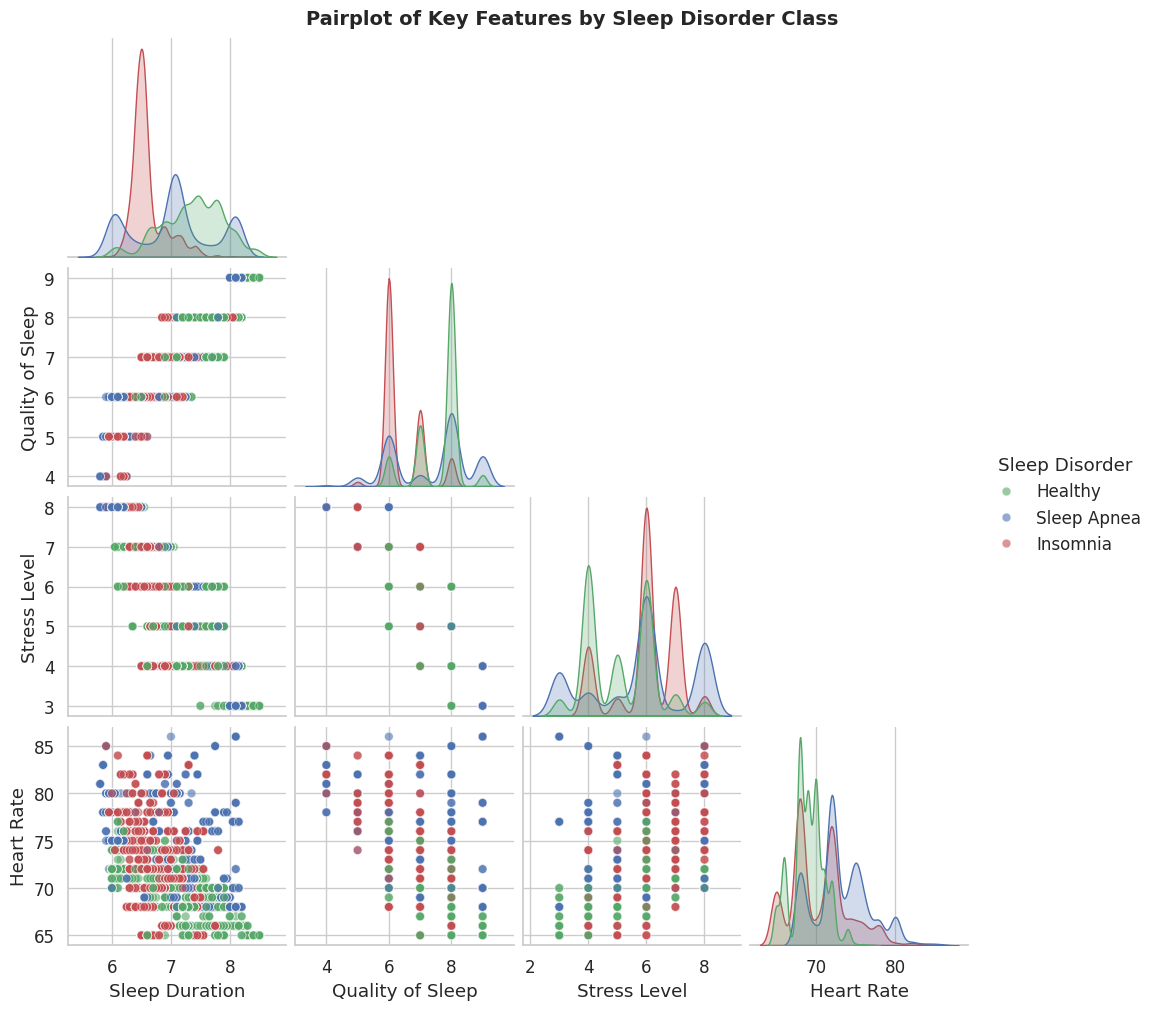

In [ ]:
# pairplot of key numerical features coloured by sleep disorder class
# reveals multivariate relationships and cluster separation between disorder classes
pairplot_features = ["Sleep Duration", "Quality of Sleep",
                     "Stress Level", "Heart Rate", "Sleep Disorder"]
pairplot_data = sleep_disorder_data[pairplot_features].dropna()
sns.pairplot(pairplot_data, hue="Sleep Disorder", palette=disorder_palette,
             diag_kind="kde", plot_kws={"alpha": 0.6, "s": 40},
             corner=True)
plt.suptitle("Pairplot of Key Features by Sleep Disorder Class",
             fontsize=14, fontweight="bold", y=1.01)
plt.show()

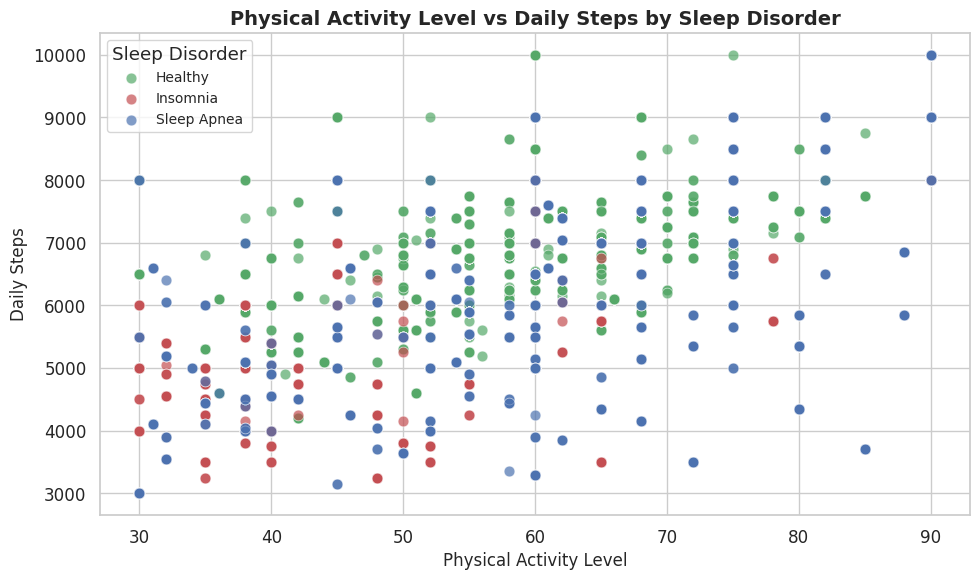

In [ ]:
# scatter plot of physical activity vs daily steps coloured by disorder
# examines whether activity levels jointly distinguish sleep disorder classes
fig, ax = plt.subplots(figsize=(10, 6))
for disorder, group in sleep_disorder_data.groupby("Sleep Disorder"):
    ax.scatter(group["Physical Activity Level"], group["Daily Steps"],
               label=disorder, color=disorder_palette[disorder],
               alpha=0.7, s=60, edgecolors="white", linewidth=0.5)
ax.set_title("Physical Activity Level vs Daily Steps by Sleep Disorder",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Physical Activity Level", fontsize=12)
ax.set_ylabel("Daily Steps", fontsize=12)
ax.legend(title="Sleep Disorder", fontsize=10)
plt.tight_layout()
plt.show()

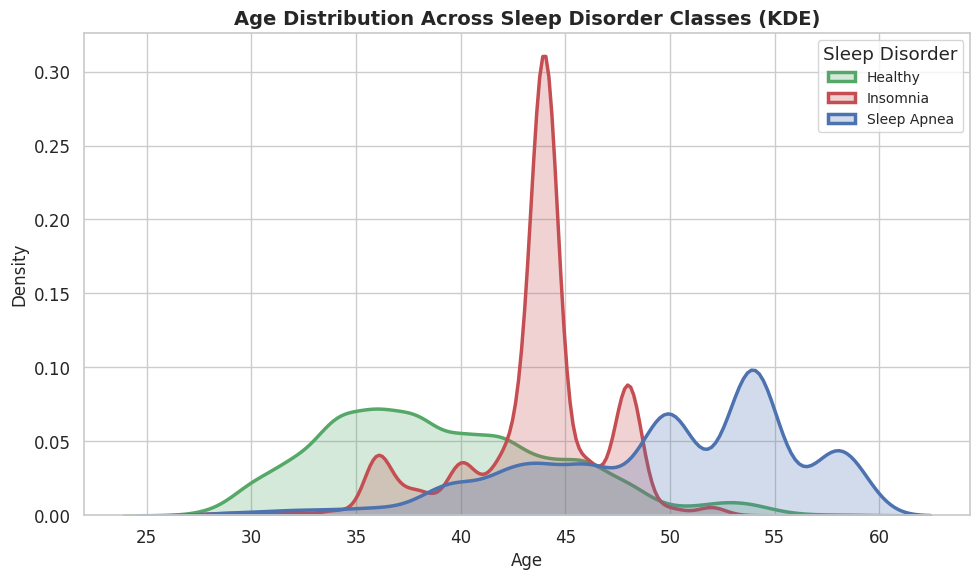

In [ ]:
# age distribution across sleep disorder classes using kde plot
# identifies whether age is a distinguishing factor between disorder groups
fig, ax = plt.subplots(figsize=(10, 6))
for disorder, group in sleep_disorder_data.groupby("Sleep Disorder"):
    sns.kdeplot(group["Age"], label=disorder,
                color=disorder_palette[disorder],
                linewidth=2.5, fill=True, alpha=0.25, ax=ax)
ax.set_title("Age Distribution Across Sleep Disorder Classes (KDE)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Age", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.legend(title="Sleep Disorder", fontsize=10)
plt.tight_layout()
plt.show()

# **Data Preprocessing**

In [ ]:
# identify all categorical columns in the dataset
categorical_cols = sleep_disorder_data.select_dtypes(include=["object"]).columns.tolist()

# loop through each categorical column and display its unique values
# this helps identify inconsistencies, typos, and unexpected categories
for col in categorical_cols:
    print(f"Column: {col}")
    print(f"Number of Unique Values: {sleep_disorder_data[col].nunique()}")
    print(f"Unique Values: {sleep_disorder_data[col].unique().tolist()}")
    print()

Column: Gender
Number of Unique Values: 2
Unique Values: ['Male', 'Female']

Column: Occupation
Number of Unique Values: 11
Unique Values: ['Doctor', 'Teacher', 'Software Engineer', 'Lawyer', 'Engineer', 'Accountant', 'Nurse', 'Scientist', 'Manager', 'Salesperson', 'Sales Representative']

Column: BMI Category
Number of Unique Values: 4
Unique Values: ['Normal Weight', 'Normal', 'Overweight', 'Obese']

Column: Blood Pressure
Number of Unique Values: 25
Unique Values: ['120/80', '135/90', '126/83', '125/80', '130/85', '140/95', '115/75', '122/80', '118/76', '128/85', '128/84', '119/77', '125/82', '118/75', '115/78', '121/79', '117/76', '140/90', '135/88', '129/84', '130/86', '139/91', '132/87', '131/86', '142/92']

Column: Sleep Disorder
Number of Unique Values: 3
Unique Values: ['Healthy', 'Sleep Apnea', 'Insomnia']



In [ ]:
# make a copy of the original dataset to preserve raw data throughout preprocessing
df = sleep_disorder_data.copy()

In [ ]:
# drop person id column as it is a unique identifier with no predictive value
df.drop(columns=["Person ID"], inplace=True)

print("Person ID column dropped successfully")
print("Dataset Shape After Dropping Person ID:", df.shape)

Person ID column dropped successfully
Dataset Shape After Dropping Person ID: (15000, 12)


In [ ]:
# parse and split blood pressure column into systolic and diastolic
# the column contains values in the format systolic/diastolic e.g. 124/70
df["Blood Pressure"] = df["Blood Pressure"].str.strip()
df["Systolic BP"]  = df["Blood Pressure"].str.split("/").str[0].astype(int)
df["Diastolic BP"] = df["Blood Pressure"].str.split("/").str[1].astype(int)

# drop the original blood pressure column after splitting
df.drop(columns=["Blood Pressure"], inplace=True)

print("\nBlood Pressure Column Split Successfully")
print("Systolic BP Range:", df["Systolic BP"].min(), "-", df["Systolic BP"].max())
print("Diastolic BP Range:", df["Diastolic BP"].min(), "-", df["Diastolic BP"].max())


Blood Pressure Column Split Successfully
Systolic BP Range: 115 - 142
Diastolic BP Range: 75 - 95


In [ ]:
# encode gender using label encoding
# binary category so label encoding is appropriate
gender_encoder = LabelEncoder()
df["Gender"] = gender_encoder.fit_transform(df["Gender"])

gender_mapping = dict(zip(gender_encoder.classes_,
                          gender_encoder.transform(gender_encoder.classes_)))
print("\nGender Encoding Mapping:", gender_mapping)


Gender Encoding Mapping: {'Female': np.int64(0), 'Male': np.int64(1)}


In [ ]:
# encode occupation using label encoding
# multiple unordered categories with no meaningful ordinal relationship
occupation_encoder = LabelEncoder()
df["Occupation"] = occupation_encoder.fit_transform(df["Occupation"])

occupation_mapping = dict(zip(occupation_encoder.classes_,
                              occupation_encoder.transform(occupation_encoder.classes_)))
print("\nOccupation Encoding Mapping:", occupation_mapping)


Occupation Encoding Mapping: {'Accountant': np.int64(0), 'Doctor': np.int64(1), 'Engineer': np.int64(2), 'Lawyer': np.int64(3), 'Manager': np.int64(4), 'Nurse': np.int64(5), 'Sales Representative': np.int64(6), 'Salesperson': np.int64(7), 'Scientist': np.int64(8), 'Software Engineer': np.int64(9), 'Teacher': np.int64(10)}


In [ ]:
# encode bmi category using ordinal mapping
# bmi categories have a meaningful order from lowest to highest health risk
bmi_mapping = {
    "Normal Weight": 1,
    "Normal":      2,
    "Overweight":  3,
    "Obese":       4
}
df["BMI Category"] = df["BMI Category"].map(bmi_mapping)

print("\nBMI Category Encoding Mapping:", bmi_mapping)
print("BMI Category Unique Values After Encoding:", sorted(df["BMI Category"].unique().tolist()))


BMI Category Encoding Mapping: {'Normal Weight': 1, 'Normal': 2, 'Overweight': 3, 'Obese': 4}
BMI Category Unique Values After Encoding: [1, 2, 3, 4]


In [ ]:
# Encode the target variable for multiclass classification
# 0 = Healthy
# 1 = Insomnia
# 2 = Sleep Apnea

df["Sleep_Disorder_Encoded"] = df["Sleep Disorder"].map({
    "Healthy": 0,
    "Insomnia": 1,
    "Sleep Apnea": 2
})

print("\nMulticlass Target Class Distribution:")
print(df["Sleep_Disorder_Encoded"].value_counts().sort_index())

print("\nClass Labels:")
print("0 = Healthy")
print("1 = Insomnia")
print("2 = Sleep Apnea")


Multiclass Target Class Distribution:
Sleep_Disorder_Encoded
0    5000
1    5000
2    5000
Name: count, dtype: int64

Class Labels:
0 = Healthy
1 = Insomnia
2 = Sleep Apnea


In [ ]:
# standardise continuous numerical columns
# standardisation scales features to zero mean and unit variance
# prevents features with larger ranges from dominating model training
scaler = StandardScaler()
continuous_cols = ["Age", "Sleep Duration",
                   "Physical Activity Level",
                   "Stress Level",
                   "Quality of Sleep",
                   "Heart Rate", "Daily Steps",
                   "Systolic BP", "Diastolic BP"]

df[continuous_cols] = scaler.fit_transform(df[continuous_cols])

print("\nContinuous Variables Standardised Successfully")
df[continuous_cols].describe().round(3)


Continuous Variables Standardised Successfully


,Age,Sleep Duration,Physical Activity Level,Stress Level,Quality of Sleep,Heart Rate,Daily Steps,Systolic BP,Diastolic BP
count,15000.000,15000.000,15000.000,15000.000,15000.000,15000.000,15000.000,15000.000,15000.000
mean,-0.000,-0.000,0.000,0.000,-0.000,-0.000,0.000,0.000,0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-2.505,-1.946,-1.780,-1.905,-2.973,-1.620,-2.854,-2.187,-1.934
25%,-0.604,-0.808,-0.888,-1.187,-1.074,-0.791,-0.598,-0.716,-0.636
50%,-0.019,0.004,0.004,0.248,-0.125,-0.237,-0.222,-0.181,-0.311
75%,0.566,0.736,0.897,0.248,0.825,0.316,0.605,1.157,1.312
max,2.174,2.443,1.789,1.683,1.775,4.189,2.410,1.424,1.312


In [ ]:
# final verification of the fully preprocessed dataset
print("\nFinal Preprocessed Dataset Shape:", df.shape)
print("\nFinal Column Data Types:")
print(df.dtypes)
print("\nFirst 5 Rows of Preprocessed Dataset:")
df.head()


Final Preprocessed Dataset Shape: (15000, 14)

Final Column Data Types:
Gender                       int64
Age                        float64
Occupation                   int64
Sleep Duration             float64
Quality of Sleep           float64
Physical Activity Level    float64
Stress Level               float64
BMI Category                 int64
Heart Rate                 float64
Daily Steps                float64
Sleep Disorder              object
Systolic BP                float64
Diastolic BP               float64
Sleep_Disorder_Encoded       int64
dtype: object

First 5 Rows of Preprocessed Dataset:


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic BP,Diastolic BP,Sleep_Disorder_Encoded
0,1,-1.334920,1,-0.564606,-0.124651,-0.590288,0.965324,1,0.039413,0.229321,Healthy,-1.518563,-1.122427,0
1,1,-0.311507,10,-0.158212,0.824948,-0.471339,-1.187495,2,-1.343822,0.154114,Healthy,0.487924,0.500500,0
2,1,-1.481121,9,-0.076933,-0.124651,0.361310,0.247718,3,0.869354,-0.522749,Healthy,-0.715968,-0.635549,0
3,1,-1.773525,1,-0.158212,-1.074250,-0.471339,0.965324,2,0.039413,-0.221921,Healthy,-1.518563,-1.122427,0
4,1,-1.042516,3,-0.239491,-0.124651,0.004461,0.247718,2,0.039413,-0.221921,Healthy,-0.849734,-1.122427,0


In [ ]:
# Drop the original Sleep Disorder column
df = df.drop(columns=["Sleep Disorder"])

# **Feature Engineering and Selection**

In [ ]:
# set visual style for all plots in this phase
sns.set_theme(style="whitegrid", font_scale=1.1)

In [ ]:
# define the target variable and separate it from the feature set
# the target variable is sleep disorder encoded numerically in preprocessing
y = df["Sleep_Disorder_Encoded"]
X = df.drop(columns=["Sleep_Disorder_Encoded"])

print("Feature Set Shape:", X.shape)
print("Target Variable Shape:", y.shape)
print("\nFeatures Available for Selection:")
print(X.columns.tolist())

Feature Set Shape: (15000, 12)
Target Variable Shape: (15000,)

Features Available for Selection:
['Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Heart Rate', 'Daily Steps', 'Systolic BP', 'Diastolic BP']


In [ ]:
# correlation analysis
# compute the absolute correlation of each feature with the target variable
# higher absolute correlation indicates stronger linear relationship with the target
correlation_with_target = X.copy()
correlation_with_target["Sleep Disorder"] = y
correlation_matrix = correlation_with_target.corr()
target_correlation = correlation_matrix["Sleep Disorder"].drop("Sleep Disorder").abs().sort_values(ascending=False)

print("\nFeature Correlation with Target Variable (Absolute Values):")
print(target_correlation)


Feature Correlation with Target Variable (Absolute Values):
Diastolic BP               0.774874
Systolic BP                0.745400
Age                        0.634696
BMI Category               0.613508
Heart Rate                 0.475796
Physical Activity Level    0.401814
Gender                     0.391342
Occupation                 0.370065
Daily Steps                0.234237
Stress Level               0.220131
Sleep Duration             0.217753
Quality of Sleep           0.111339
Name: Sleep Disorder, dtype: float64


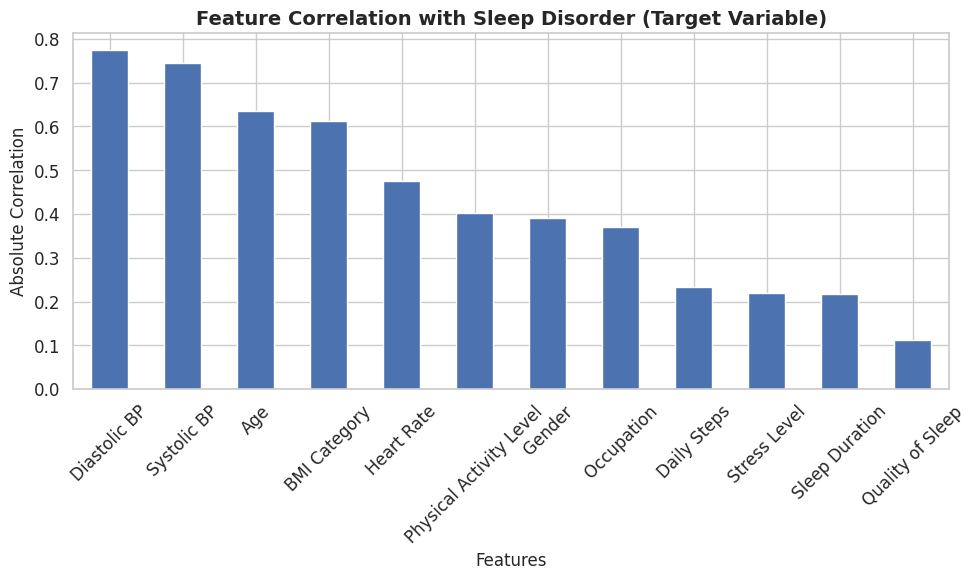

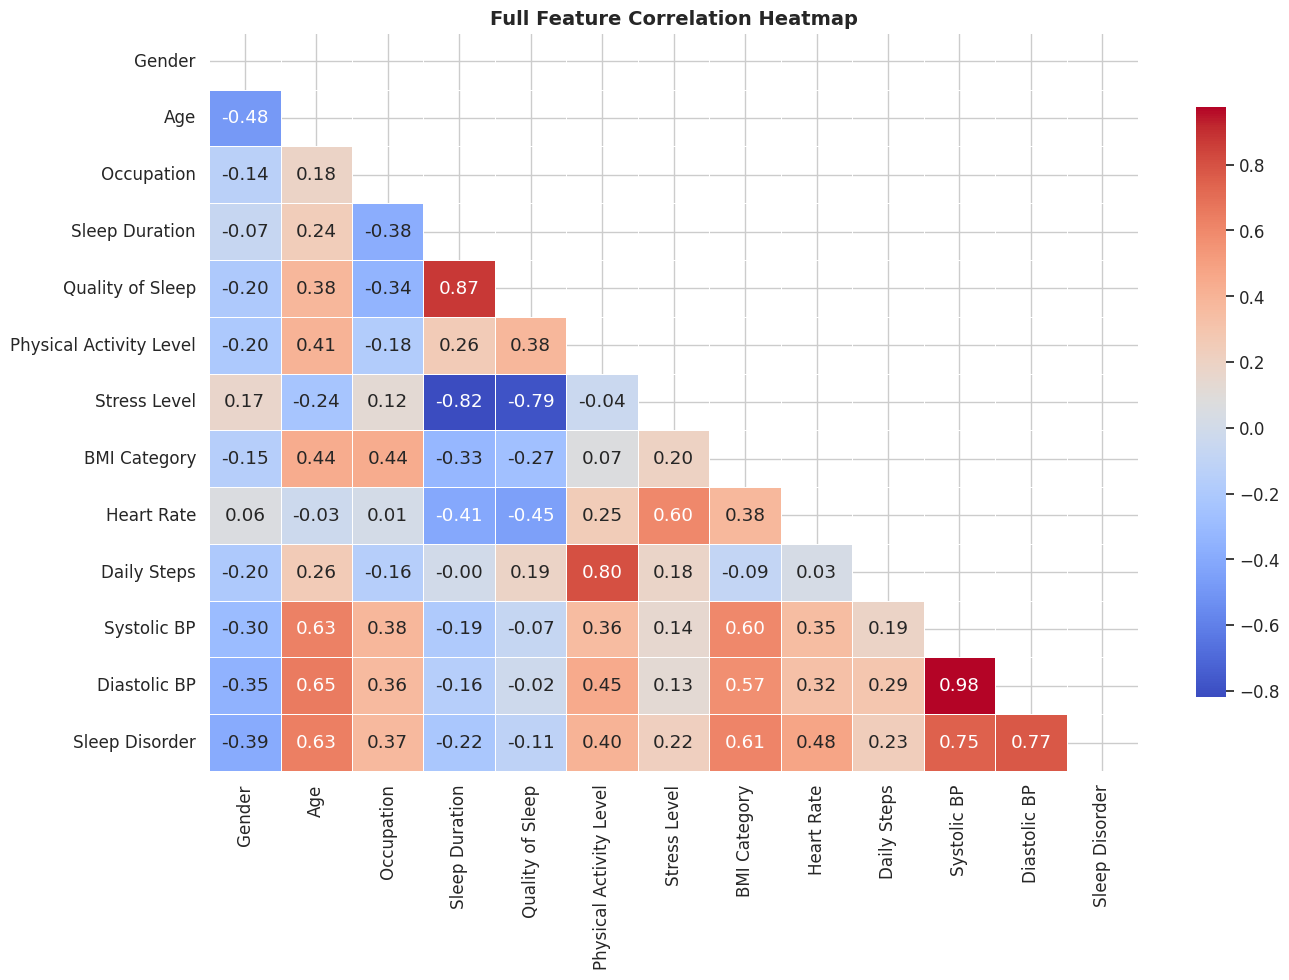

In [ ]:
# plot the correlation of each feature with the target variable
fig, ax = plt.subplots(figsize=(10, 6))
target_correlation.plot(kind="bar", color="#4C72B0", edgecolor="white", ax=ax)
ax.set_title("Feature Correlation with Sleep Disorder (Target Variable)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Features", fontsize=12)
ax.set_ylabel("Absolute Correlation", fontsize=12)
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

# plot the full correlation heatmap across all features
fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.5, linecolor="white",
            cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Full Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# define the final feature set and target variable
# X contains the selected predictive features
# y contains the encoded sleep disorder target variable
print("\nFinal Feature Set (X) Columns:")
print(X.columns.tolist())

print("\nTarget Variable (y) Distribution:")
print(y.value_counts())


Final Feature Set (X) Columns:
['Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Heart Rate', 'Daily Steps', 'Systolic BP', 'Diastolic BP']

Target Variable (y) Distribution:
Sleep_Disorder_Encoded
0    5000
2    5000
1    5000
Name: count, dtype: int64


# **Data Splitting and Handling Class Imbalance**

In [ ]:
#  split the data into training and testing sets using 80/20 ratio
# random state is fixed at 42 to ensure reproducibility across runs
# stratify ensures class proportions are preserved in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTraining Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)


Training Set Shape: (12000, 12)
Testing Set Shape: (3000, 12)
Training Target Shape: (12000,)
Testing Target Shape: (3000,)


# **Model Development and Training**

In [ ]:
# Create stratified 10-fold cross-validation
# shuffle=True prevents the original systematic ordering
# of the dataset from affecting the folds
# random_state=42 ensures reproducibility

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

# Train Random Forest classifier
# n_estimators defines the number of decision trees
# max_depth=None allows trees to grow until stopping criteria are reached
# min_samples_split defines the minimum samples required to split a node
# min_samples_leaf defines the minimum samples required in a leaf
# random_state=42 ensures reproducibility

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

# Perform 10-fold stratified cross-validation on the training data
rf_cv_scores = cross_val_score(
    random_forest_model,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

# Train the final Random Forest model on the complete training dataset
random_forest_model.fit(X_train, y_train)

# Generate predictions on the unseen test set
rf_predictions = random_forest_model.predict(X_test)

# Calculate test set accuracy
rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

print("\nRandom Forest Training Complete")
print(f"Cross-Validation Accuracy Scores: {rf_cv_scores.round(4)}")
print(f"Mean CV Accuracy: {rf_cv_scores.mean():.4f}")
print(f"Standard Deviation: {rf_cv_scores.std():.4f}")
print(f"Test Set Accuracy: {rf_accuracy:.4f}")


Random Forest Training Complete
Cross-Validation Accuracy Scores: [0.9667 0.965  0.965  0.9675 0.9675 0.9658 0.9533 0.9692 0.9575 0.9567]
Mean CV Accuracy: 0.9634
Standard Deviation: 0.0052
Test Set Accuracy: 0.9630


In [ ]:
# Create stratified 10-fold cross-validation
# shuffle=True prevents the original systematic ordering
# of the dataset from affecting the folds
cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

# Train Support Vector Machine classifier
# RBF kernel captures non-linear relationships between features
# C controls the regularisation strength
# gamma="scale" automatically determines the kernel coefficient
svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    random_state=42
)

# Perform 10-fold stratified cross-validation
svm_cv_scores = cross_val_score(
    svm_model,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

# Train the final SVM model on the complete training dataset
svm_model.fit(X_train, y_train)

# Generate predictions on the unseen test set
svm_predictions = svm_model.predict(X_test)

print("\nSupport Vector Machine Training Complete")
print(f"Cross-Validation Accuracy Scores: {svm_cv_scores.round(4)}")
print(f"Mean CV Accuracy: {svm_cv_scores.mean():.4f}")
print(f"Standard Deviation: {svm_cv_scores.std():.4f}")


Support Vector Machine Training Complete
Cross-Validation Accuracy Scores: [0.9433 0.945  0.9375 0.9342 0.9292 0.9483 0.93   0.9492 0.9275 0.9333]
Mean CV Accuracy: 0.9377
Standard Deviation: 0.0077


In [ ]:
# Create stratified 10-fold cross-validation
# shuffle=True prevents the original systematic ordering
# of the dataset from affecting the folds
# random_state=42 ensures reproducibility

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

# Train Multilayer Perceptron (MLP) Neural Network
# hidden_layer_sizes=(128, 64) creates two hidden layers
# with 128 and 64 neurons respectively
# ReLU activation introduces non-linearity
# Adam optimiser performs gradient-based weight optimisation
# alpha controls L2 regularisation to reduce overfitting
# max_iter=500 allows sufficient iterations for convergence
# early_stopping=True stops training when validation performance
# stops improving
# validation_fraction=0.1 reserves 10% of the training data
# for internal validation during training
# random_state=42 ensures reproducibility

mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    alpha=0.001,
    learning_rate="adaptive",
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)

# Perform 10-fold stratified cross-validation
# using only the training data
mlp_cv_scores = cross_val_score(
    mlp_model,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

# Train the final MLP model on the complete training dataset
mlp_model.fit(X_train, y_train)

# Generate predictions on the unseen test set
mlp_predictions = mlp_model.predict(X_test)

print("\nNeural Network (MLP) Training Complete")
print(f"Cross-Validation Accuracy Scores: {mlp_cv_scores.round(4)}")
print(f"Mean CV Accuracy: {mlp_cv_scores.mean():.4f}")
print(f"Standard Deviation: {mlp_cv_scores.std():.4f}")


Neural Network (MLP) Training Complete
Cross-Validation Accuracy Scores: [0.9533 0.95   0.9533 0.9558 0.94   0.9675 0.955  0.9592 0.955  0.9542]
Mean CV Accuracy: 0.9543
Standard Deviation: 0.0065


In [ ]:
# Create stratified 10-fold cross-validation
# shuffle=True prevents the original systematic ordering
# of the dataset from affecting the folds
# random_state=42 ensures reproducibility

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

# Train K-Nearest Neighbours classifier
# n_neighbors=5 uses the five nearest observations
# weights="uniform" gives equal weight to all neighbours
# metric="minkowski" with p=2 is equivalent to Euclidean distance

knn_model = KNeighborsClassifier(
    n_neighbors=5,
    weights="uniform",
    metric="minkowski",
    p=2
)

# Perform 10-fold stratified cross-validation
# using only the training data
knn_cv_scores = cross_val_score(
    knn_model,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

# Train the final KNN model on the complete training dataset
knn_model.fit(X_train, y_train)

# Generate predictions on the unseen test set
knn_predictions = knn_model.predict(X_test)

print("\nK-Nearest Neighbours Training Complete")
print(f"Cross-Validation Accuracy Scores: {knn_cv_scores.round(4)}")
print(f"Mean CV Accuracy: {knn_cv_scores.mean():.4f}")
print(f"Standard Deviation: {knn_cv_scores.std():.4f}")


K-Nearest Neighbours Training Complete
Cross-Validation Accuracy Scores: [0.9517 0.9483 0.9417 0.95   0.9508 0.955  0.9483 0.9525 0.9425 0.9475]
Mean CV Accuracy: 0.9488
Standard Deviation: 0.0040


In [ ]:
# compile cross validation summary for all four models
print("\n")
print("Cross-Validation Summary (10-Fold)")
print(f"{'Model':<35} {'Mean Accuracy':>15} {'Std Deviation':>15}")
print("-" * 65)
print(f"{'Random Forest':<35} {rf_cv_scores.mean():>15.4f} {rf_cv_scores.std():>15.4f}")
print(f"{'Support Vector Machine':<35} {svm_cv_scores.mean():>15.4f} {svm_cv_scores.std():>15.4f}")
print(f"{'Neural Network (MLP)':<35} {mlp_cv_scores.mean():>15.4f} {mlp_cv_scores.std():>15.4f}")
print(f"{'K-Nearest Neighbours':<35} {knn_cv_scores.mean():>15.4f} {knn_cv_scores.std():>15.4f}")



Cross-Validation Summary (10-Fold)
Model                                 Mean Accuracy   Std Deviation
-----------------------------------------------------------------
Random Forest                                0.9634          0.0052
Support Vector Machine                       0.9377          0.0077
Neural Network (MLP)                         0.9543          0.0065
K-Nearest Neighbours                         0.9488          0.0040


# **Model Evaluation**

In [ ]:
# set consistent visual style across all evaluation plots
sns.set_theme(style="whitegrid", font_scale=1.1)

In [ ]:
# Define class names for confusion matrix and ROC curve labelling
# These correspond to the multiclass target encoding
class_names = ["Healthy", "Insomnia", "Sleep Apnea"]

In [ ]:
# compute evaluation metrics for each model individually
# metrics are computed on the unseen test set predictions
# average macro treats all classes equally regardless of support size

# random forest metrics
rf_accuracy  = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions, average="macro", zero_division=0)
rf_recall    = recall_score(y_test, rf_predictions, average="macro", zero_division=0)
rf_f1        = f1_score(y_test, rf_predictions, average="macro", zero_division=0)

# svm metrics
svm_accuracy  = accuracy_score(y_test, svm_predictions)
svm_precision = precision_score(y_test, svm_predictions, average="macro", zero_division=0)
svm_recall    = recall_score(y_test, svm_predictions, average="macro", zero_division=0)
svm_f1        = f1_score(y_test, svm_predictions, average="macro", zero_division=0)

# mlp neural network metrics
mlp_accuracy  = accuracy_score(y_test, mlp_predictions)
mlp_precision = precision_score(y_test, mlp_predictions, average="macro", zero_division=0)
mlp_recall    = recall_score(y_test, mlp_predictions, average="macro", zero_division=0)
mlp_f1        = f1_score(y_test, mlp_predictions, average="macro", zero_division=0)

# knn metrics
knn_accuracy  = accuracy_score(y_test, knn_predictions)
knn_precision = precision_score(y_test, knn_predictions, average="macro", zero_division=0)
knn_recall    = recall_score(y_test, knn_predictions, average="macro", zero_division=0)
knn_f1        = f1_score(y_test, knn_predictions, average="macro", zero_division=0)

In [ ]:
# compile comparative performance summary table
# organises all evaluation metrics side by side for direct model comparison

summary_data = {
    "Model": [
        "Random Forest",
        "Support Vector Machine",
        "Neural Network (MLP)",
        "K-Nearest Neighbours"
    ],
    "Accuracy": [
        round(rf_accuracy,  4),
        round(svm_accuracy, 4),
        round(mlp_accuracy, 4),
        round(knn_accuracy, 4)
    ],
    "Precision": [
        round(rf_precision,  4),
        round(svm_precision, 4),
        round(mlp_precision, 4),
        round(knn_precision, 4)
    ],
    "Recall": [
        round(rf_recall,  4),
        round(svm_recall, 4),
        round(mlp_recall, 4),
        round(knn_recall, 4)
    ],
    "F1 Score": [
        round(rf_f1,  4),
        round(svm_f1, 4),
        round(mlp_f1, 4),
        round(knn_f1, 4)
    ]
}

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values("Accuracy", ascending=False).reset_index(drop=True)

print("\nComparative Model Performance Summary")
print(summary_df.to_string(index=False))


Comparative Model Performance Summary
                 Model  Accuracy  Precision  Recall  F1 Score
         Random Forest    0.9630     0.9630  0.9630    0.9630
  Neural Network (MLP)    0.9530     0.9531  0.9530    0.9529
  K-Nearest Neighbours    0.9520     0.9520  0.9520    0.9519
Support Vector Machine    0.9363     0.9364  0.9363    0.9363


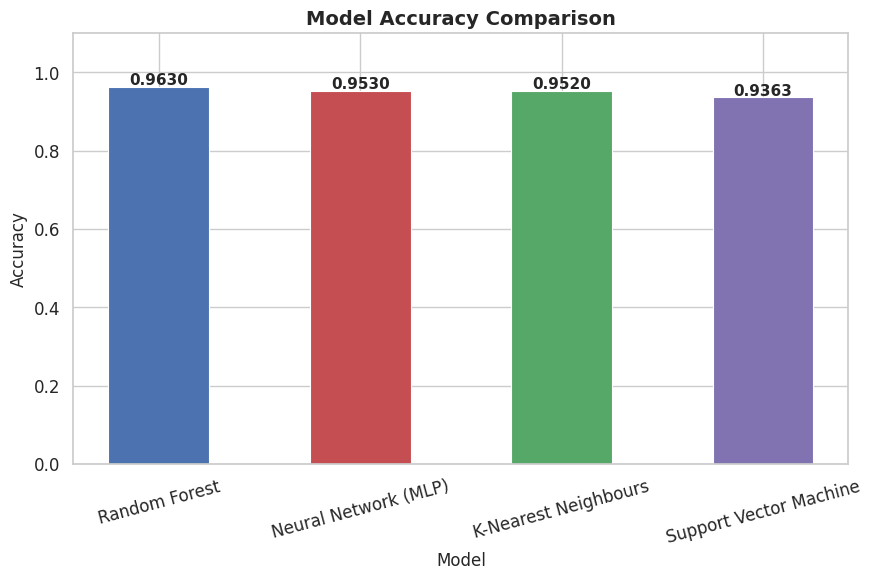


Best Performing Model: Random Forest
Accuracy  : 0.963
Precision : 0.963
Recall    : 0.963
F1 Score  : 0.963


In [ ]:
# bar chart comparing model accuracies
# provides a clear visual comparison of accuracy across all four models

fig, ax = plt.subplots(figsize=(9, 6))
bar_colors = ["#4C72B0", "#C44E52", "#55A868", "#8172B2"]
bars = ax.bar(summary_df["Model"], summary_df["Accuracy"],
              color=bar_colors, edgecolor="white", linewidth=0.8, width=0.5)

# annotate each bar with its accuracy value
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{bar.get_height():.4f}",
            ha="center", fontsize=11, fontweight="bold")

ax.set_title("Model Accuracy Comparison", fontsize=14, fontweight="bold")
ax.set_xlabel("Model", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_ylim(0, 1.1)
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()


# identify and print the best performing model based on accuracy
best_model = summary_df.iloc[0]
print(f"\nBest Performing Model: {best_model['Model']}")
print(f"Accuracy  : {best_model['Accuracy']}")
print(f"Precision : {best_model['Precision']}")
print(f"Recall    : {best_model['Recall']}")
print(f"F1 Score  : {best_model['F1 Score']}")


Confusion Matrix: Random Forest
                                 Healthy            Insomnia         Sleep Apnea
Healthy                              944                  29                  27
Insomnia                              15                 973                  12
Sleep Apnea                           21                   7                 972


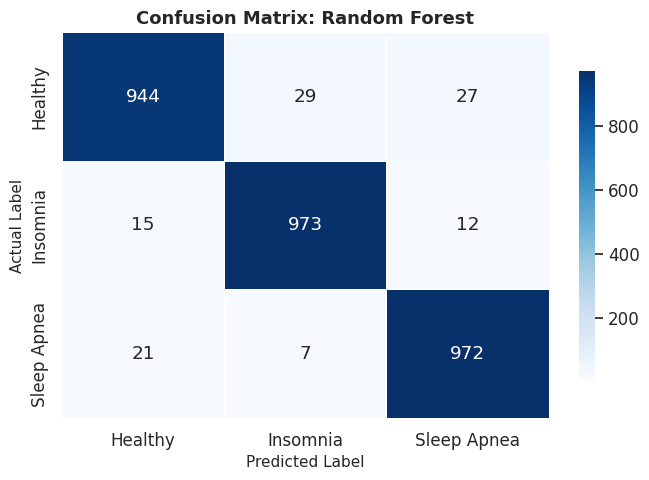


Confusion Matrix: Support Vector Machine
                                 Healthy            Insomnia         Sleep Apnea
Healthy                              925                  40                  35
Insomnia                              44                 933                  23
Sleep Apnea                           38                  11                 951


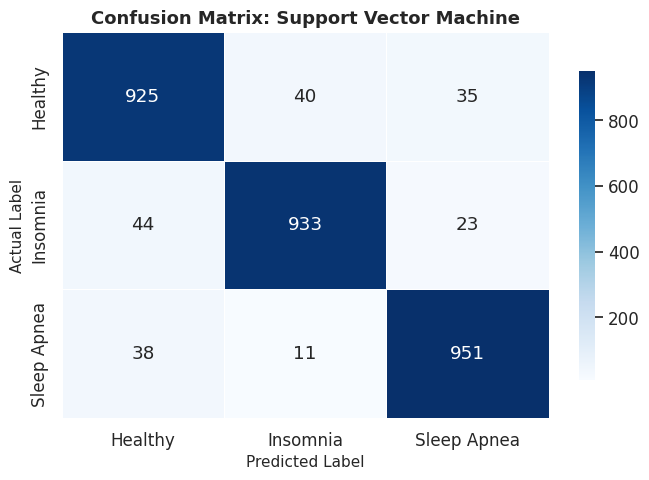


Confusion Matrix: Neural Network (MLP)
                                 Healthy            Insomnia         Sleep Apnea
Healthy                              930                  41                  29
Insomnia                              14                 967                  19
Sleep Apnea                           25                  13                 962


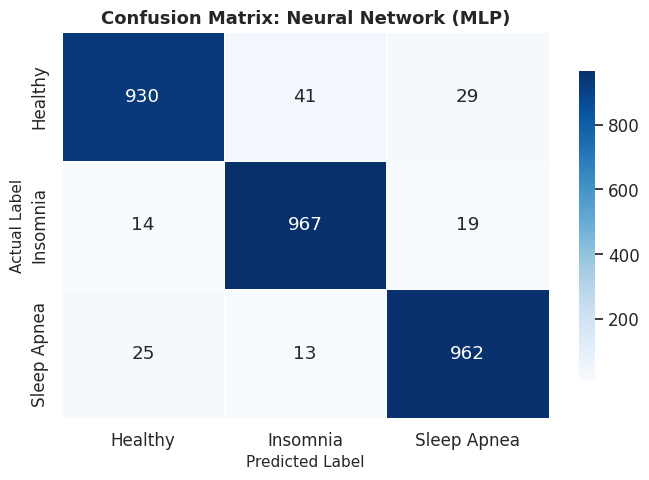


Confusion Matrix: K-Nearest Neighbours
                                 Healthy            Insomnia         Sleep Apnea
Healthy                              931                  36                  33
Insomnia                              21                 965                  14
Sleep Apnea                           24                  16                 960


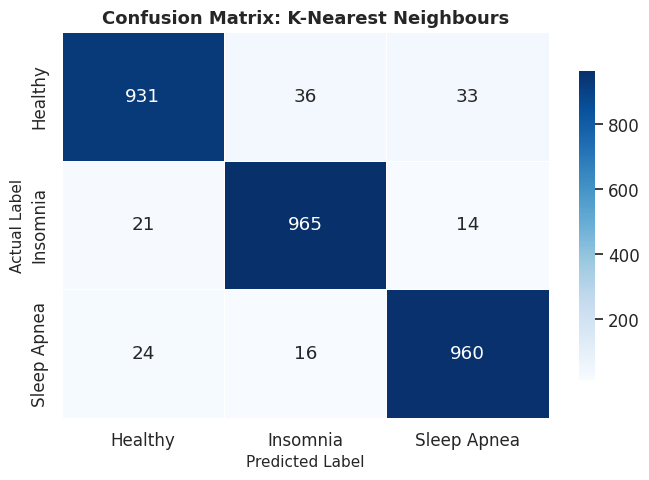

In [ ]:
# print and plot confusion matrix for each model
# confusion matrix shows correct and incorrect predictions per class
# rows represent actual classes and columns represent predicted classes

models_info = [
    ("Random Forest",            y_test, rf_predictions,  "#4C72B0"),
    ("Support Vector Machine",   y_test, svm_predictions, "#C44E52"),
    ("Neural Network (MLP)",     y_test, mlp_predictions, "#55A868"),
    ("K-Nearest Neighbours",     y_test, knn_predictions, "#8172B2"),
]

for model_name, y_true, y_pred, color in models_info:

    # print confusion matrix numerically
    cm = confusion_matrix(y_true, y_pred)
    print(f"\nConfusion Matrix: {model_name}")
    print(f"{'':20}", end="")
    for cn in class_names:
        print(f"{cn:>20}", end="")
    print()
    for i, row in enumerate(cm):
        print(f"{class_names[i]:20}", end="")
        for val in row:
            print(f"{val:>20}", end="")
        print()

    # plot confusion matrix as a heatmap
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names,
                yticklabels=class_names,
                linewidths=0.5, linecolor="white",
                cbar_kws={"shrink": 0.8}, ax=ax)
    ax.set_title(f"Confusion Matrix: {model_name}",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Predicted Label", fontsize=11)
    ax.set_ylabel("Actual Label", fontsize=11)
    plt.tight_layout()
    plt.show()

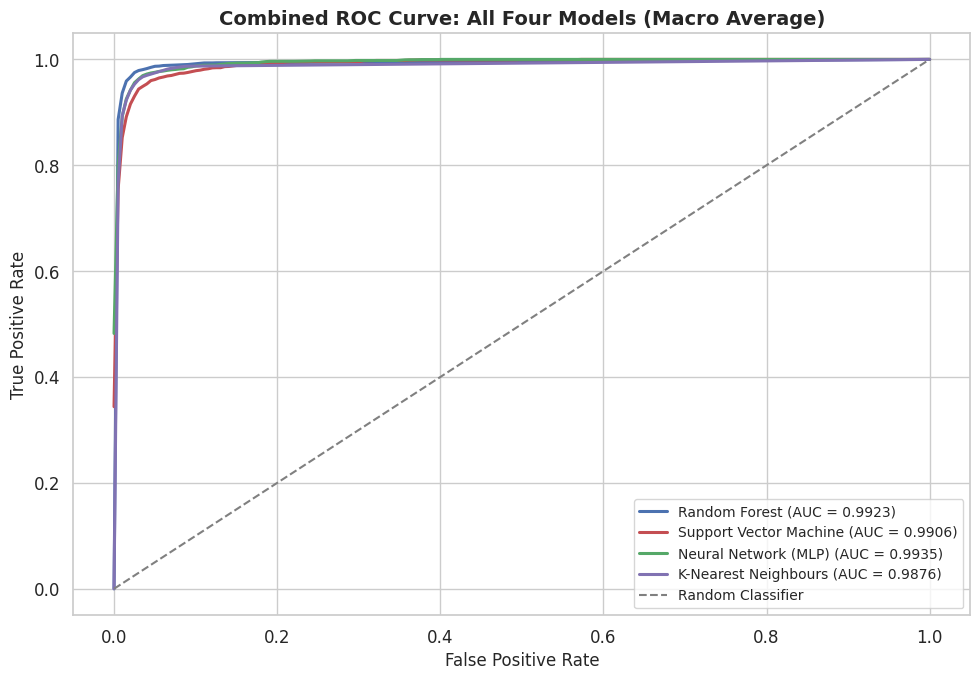

In [ ]:
# combined roc curve plot for all four models
# roc curves are computed using one vs rest strategy for multiclass classification
# y_test is binarized to enable per class roc computation
# auc score summarises the area under each curve where 1.0 is perfect

# binarize the test labels for multiclass roc computation
n_classes   = len(class_names)
y_test_bin  = label_binarize(y_test, classes=np.unique(y_test))

# collect predicted probabilities for all four models
models_proba = [
    ("Random Forest",          random_forest_model.predict_proba(X_test), "#4C72B0"),
    ("Support Vector Machine", svm_model.predict_proba(X_test),           "#C44E52"),
    ("Neural Network (MLP)",   mlp_model.predict_proba(X_test),           "#55A868"),
    ("K-Nearest Neighbours",   knn_model.predict_proba(X_test),           "#8172B2"),
]

fig, ax = plt.subplots(figsize=(10, 7))

for model_name, y_proba, color in models_proba:

    # compute macro average roc curve across all classes
    fpr_all = []
    tpr_all = []

    for i in range(n_classes):
        fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        fpr_all.append(fpr_i)
        tpr_all.append(tpr_i)

    # interpolate all roc curves to a common fpr axis for macro averaging
    mean_fpr = np.linspace(0, 1, 200)
    mean_tpr = np.zeros_like(mean_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(mean_fpr, fpr_all[i], tpr_all[i])
    mean_tpr /= n_classes
    mean_auc = auc(mean_fpr, mean_tpr)

    ax.plot(mean_fpr, mean_tpr, color=color, linewidth=2.2,
            label=f"{model_name} (AUC = {mean_auc:.4f})")

# plot the diagonal reference line representing random classifier performance
ax.plot([0, 1], [0, 1], linestyle="--", color="grey",
        linewidth=1.5, label="Random Classifier")

ax.set_title("Combined ROC Curve: All Four Models (Macro Average)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.legend(loc="lower right", fontsize=10)
plt.tight_layout()
plt.show()

# **Interpretability of Models**

In [ ]:
# Create SHAP TreeExplainer for the Random Forest model
explainer = shap.TreeExplainer(random_forest_model)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

print("SHAP values calculated successfully.")

SHAP values calculated successfully.



SHAP Summary: Healthy


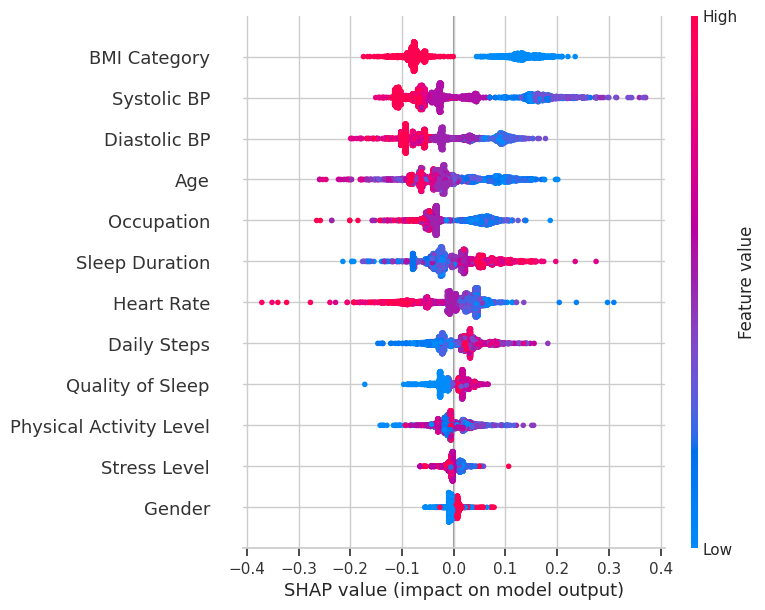


SHAP Summary: Insomnia


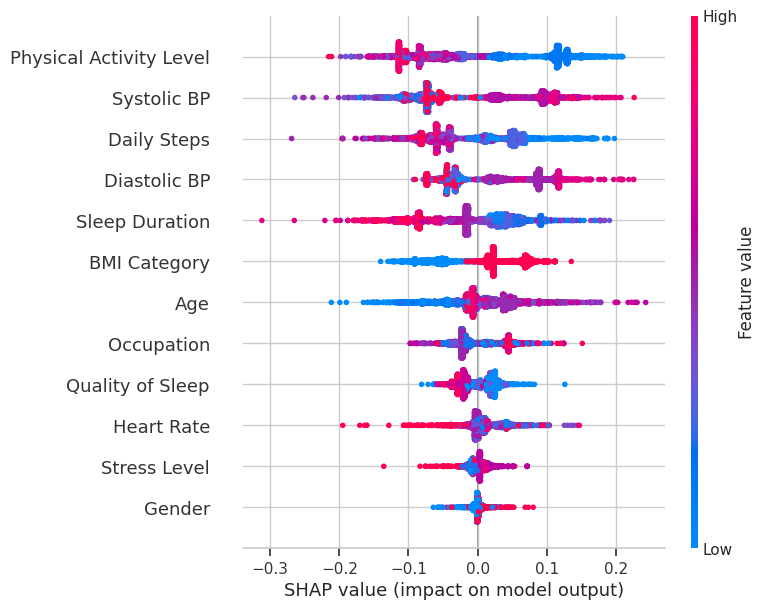


SHAP Summary: Sleep Apnea


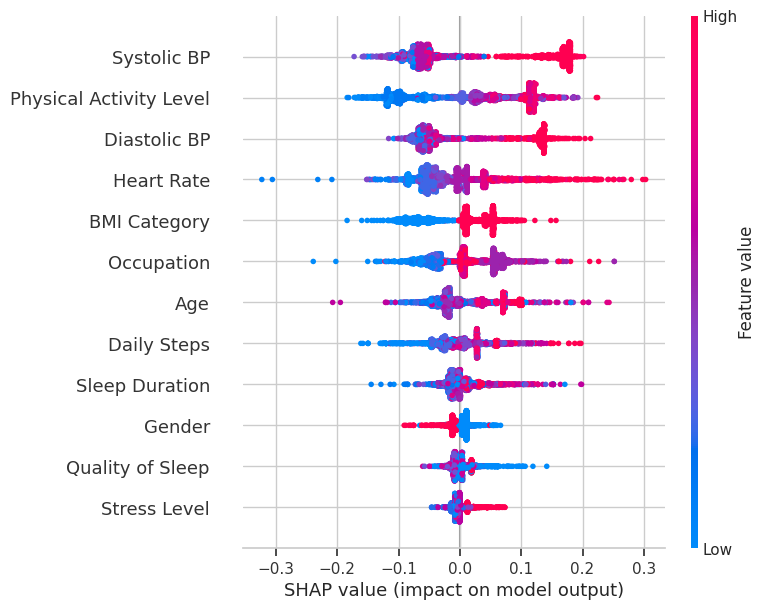

In [ ]:
# Generate SHAP summary plots for each class

if isinstance(shap_values, list):

    for class_index, class_name in enumerate(class_names):

        print(f"\nSHAP Summary: {class_name}")

        shap.summary_plot(
            shap_values[class_index],
            X_test,
            feature_names=X_test.columns,
            show=True
        )

else:

    for class_index, class_name in enumerate(class_names):

        print(f"\nSHAP Summary: {class_name}")

        shap.summary_plot(
            shap_values[:, :, class_index],
            X_test,
            feature_names=X_test.columns,
            show=True
        )

In [ ]:
# Calculate mean absolute SHAP importance across all classes

if isinstance(shap_values, list):

    shap_abs = np.mean(
        [np.abs(values) for values in shap_values],
        axis=0
    )

else:

    shap_abs = np.mean(
        np.abs(shap_values),
        axis=2
    )

# Calculate average importance for each feature
mean_shap_importance = np.mean(shap_abs, axis=0)

# Create feature importance dataframe
shap_importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean Absolute SHAP": mean_shap_importance
})

# Sort from most to least important
shap_importance_df = shap_importance_df.sort_values(
    "Mean Absolute SHAP",
    ascending=False
)

print("\nOverall SHAP Feature Importance:")
print(shap_importance_df.head(15))


Overall SHAP Feature Importance:
                    Feature  Mean Absolute SHAP
10              Systolic BP            0.088618
11             Diastolic BP            0.067018
7              BMI Category            0.065394
5   Physical Activity Level            0.063474
1                       Age            0.042885
9               Daily Steps            0.041944
2                Occupation            0.041606
3            Sleep Duration            0.038429
8                Heart Rate            0.036076
4          Quality of Sleep            0.017748
6              Stress Level            0.009106
0                    Gender            0.007581


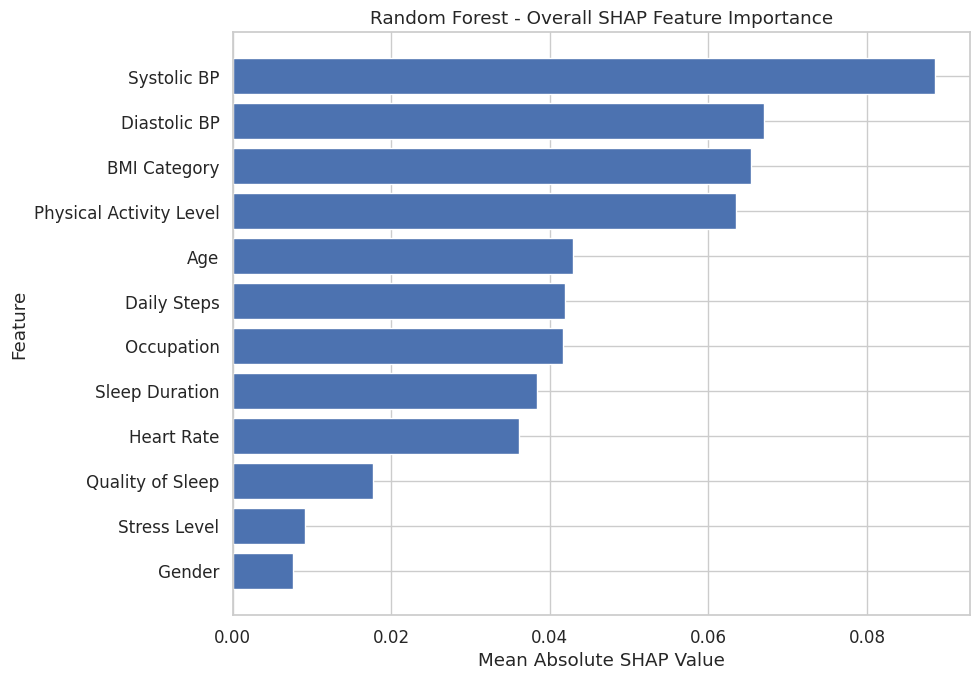

In [ ]:
# Plot overall SHAP feature importance

top_features = shap_importance_df.head(15).sort_values(
    "Mean Absolute SHAP"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Mean Absolute SHAP"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title(
    "Random Forest - Overall SHAP Feature Importance"
)

plt.tight_layout()
plt.show()

In [ ]:
# Identify the most important feature
top_feature = shap_importance_df.iloc[0]["Feature"]

print("Most important feature:", top_feature)

Most important feature: Systolic BP


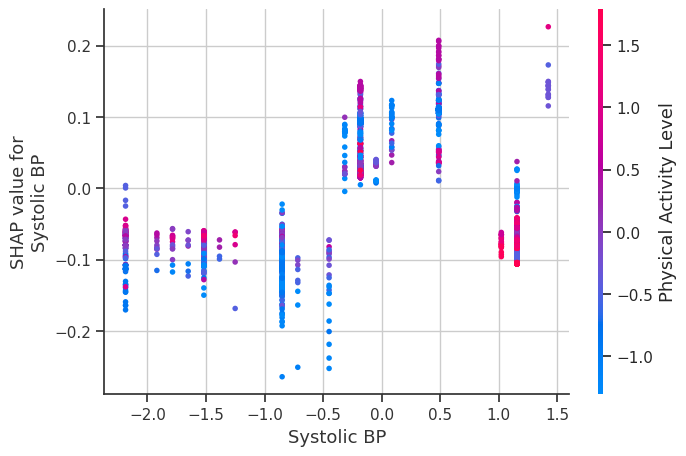

In [ ]:
# SHAP dependence plot for the most important feature
# for the Insomnia class

insomnia_class = 1

if isinstance(shap_values, list):

    class_shap = shap_values[insomnia_class]

else:

    class_shap = shap_values[:, :, insomnia_class]

shap.dependence_plot(
    top_feature,
    class_shap,
    X_test,
    feature_names=X_test.columns
)

In [ ]:
# Select one test observation for individual explanation

sample_index = 0

sample = X_test.iloc[[sample_index]]

actual_class = y_test.iloc[sample_index]
predicted_class = random_forest_model.predict(sample)[0]

print("Actual class:",
      class_names[actual_class])

print("Predicted class:",
      class_names[predicted_class])

Actual class: Insomnia
Predicted class: Insomnia



SHAP explanation for Healthy


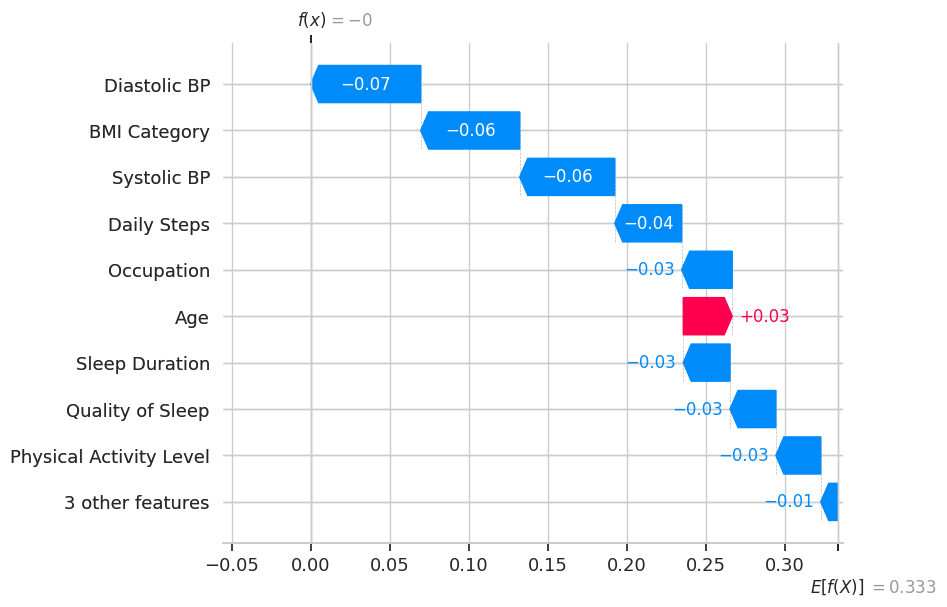


SHAP explanation for Insomnia


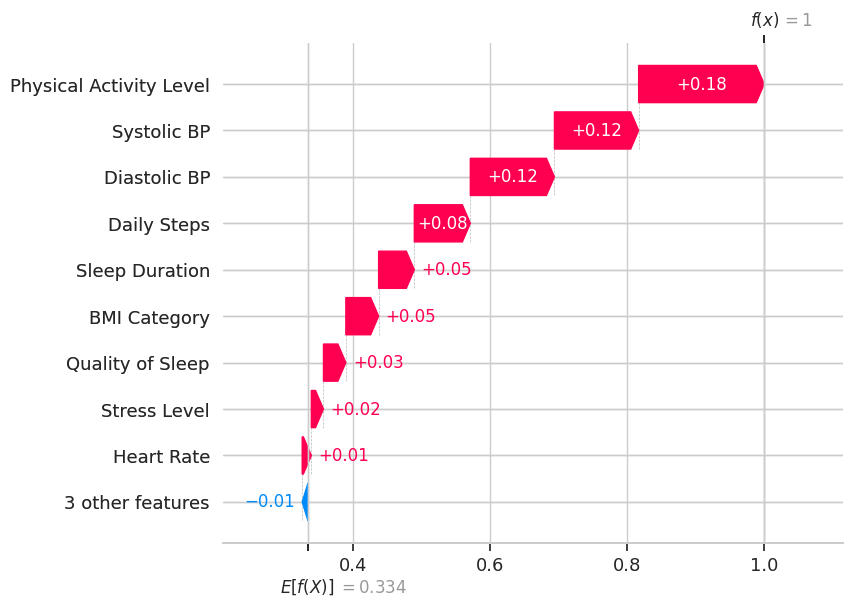


SHAP explanation for Sleep Apnea


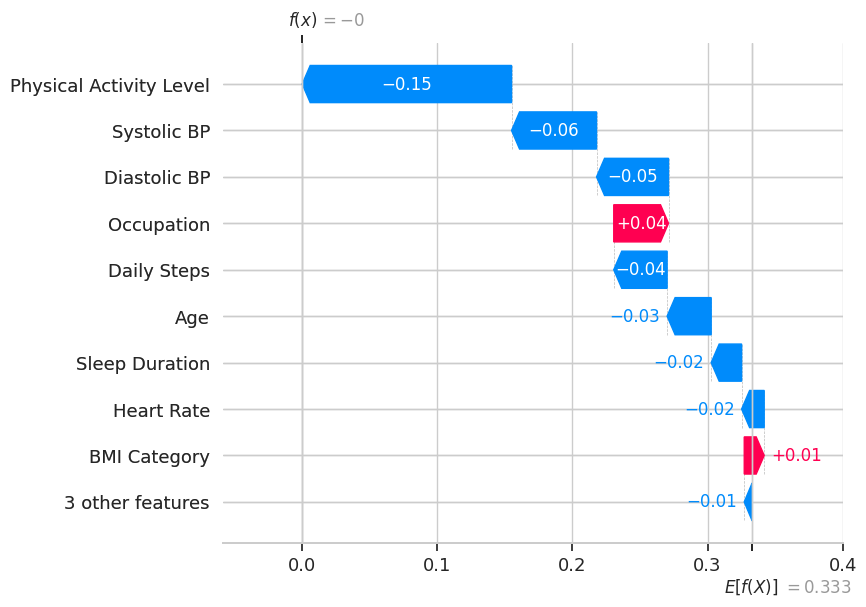

In [ ]:
# Generate SHAP explanation for the selected observation

if isinstance(shap_values, list):

    sample_shap = [
        values[sample_index]
        for values in shap_values
    ]

    for class_index, class_name in enumerate(class_names):

        print(f"\nSHAP explanation for {class_name}")

        shap.plots._waterfall.waterfall_legacy(
            explainer.expected_value[class_index],
            sample_shap[class_index],
            feature_names=X_test.columns
        )

else:

    for class_index, class_name in enumerate(class_names):

        print(f"\nSHAP explanation for {class_name}")

        shap.plots._waterfall.waterfall_legacy(
            explainer.expected_value[class_index],
            shap_values[sample_index, :, class_index],
            feature_names=X_test.columns
        )

In [ ]:
# Create LIME explainer

lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=class_names,
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

In [ ]:
# Select observation to explain
sample_index = 0

sample = X_test.iloc[sample_index].values

actual_class = y_test.iloc[sample_index]
predicted_class = random_forest_model.predict(
    X_test.iloc[[sample_index]]
)[0]

print("Actual class:",
      class_names[actual_class])

print("Predicted class:",
      class_names[predicted_class])

Actual class: Insomnia
Predicted class: Insomnia


In [ ]:
# Generate LIME explanation

lime_explanation = lime_explainer.explain_instance(
    sample,
    random_forest_model.predict_proba,
    num_features=10,
    top_labels=3
)

# Display the explanation
lime_explanation.show_in_notebook(show_table=True)

In [ ]:
# Display LIME feature contributions for the predicted class

print(
    f"\nLIME Explanation for Predicted Class: "
    f"{class_names[predicted_class]}"
)

lime_features = lime_explanation.as_list(
    label=predicted_class
)

for feature, contribution in lime_features:
    print(f"{feature}: {contribution:.4f}")


LIME Explanation for Predicted Class: Insomnia
Physical Activity Level <= -0.89: 0.1228
Age <= -0.60: -0.0884
Daily Steps <= -0.60: 0.0725
-0.18 < Systolic BP <= 1.16: 0.0614
Sleep Duration <= -0.81: 0.0603
2.00 < Occupation <= 5.00: -0.0342
-0.31 < Diastolic BP <= 1.31: 0.0205
Quality of Sleep <= -1.07: 0.0205
-0.24 < Heart Rate <= 0.32: -0.0180
Gender <= 0.00: 0.0096


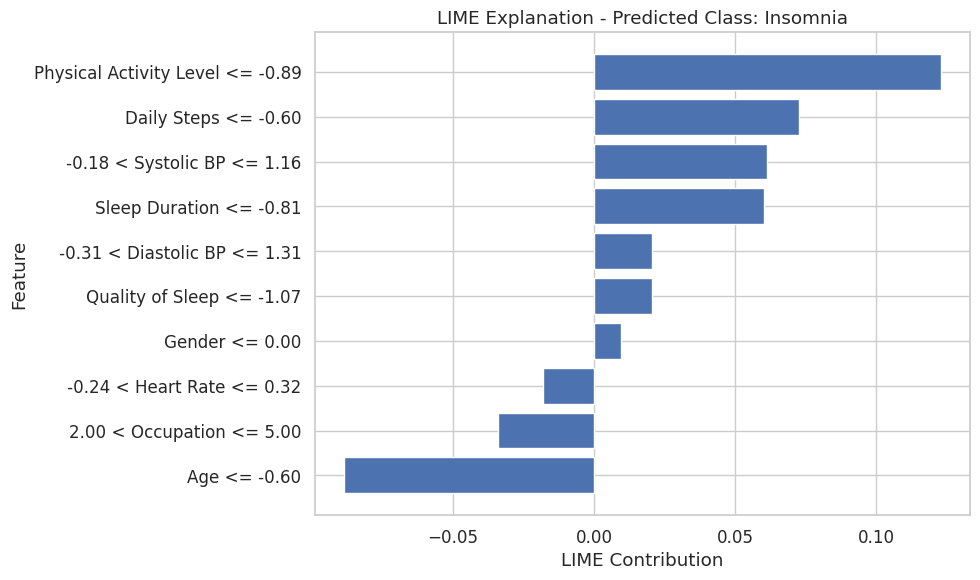

In [ ]:
# Extract LIME feature contributions

lime_df = pd.DataFrame(
    lime_features,
    columns=["Feature", "Contribution"]
)

lime_df = lime_df.sort_values(
    "Contribution"
)

plt.figure(figsize=(10, 6))

plt.barh(
    lime_df["Feature"],
    lime_df["Contribution"]
)

plt.xlabel("LIME Contribution")
plt.ylabel("Feature")
plt.title(
    f"LIME Explanation - Predicted Class: "
    f"{class_names[predicted_class]}"
)

plt.tight_layout()
plt.show()

# **Predictions on Input Data**

In [ ]:
!pip install gradio --quiet
!npm install -g localtunnel --silent

In [ ]:
import gradio as gr
import subprocess
import threading
import time
import urllib.request
from IPython.utils import io

In [ ]:
def predict_sleep_disorder(
    gender, age, occupation, sleep_duration,
    quality_of_sleep, physical_activity, stress_level,
    bmi_category, heart_rate, daily_steps,
    systolic_bp, diastolic_bp
):

    # encode gender exactly as the label encoder did during preprocessing
    # use the fitted gender_encoder from the preprocessing pipeline
    gender_encoded = gender_encoder.transform([gender])[0]

    # encode occupation exactly as the label encoder did during preprocessing
    # use the fitted occupation_encoder from the preprocessing pipeline
    occupation_encoded = occupation_encoder.transform([occupation])[0]

    # encode bmi category exactly as the ordinal mapping did during preprocessing
    bmi_mapping_input = {
        "Normal Weight": 1,
        "Normal":        2,
        "Overweight":    3,
        "Obese":         4
    }
    bmi_encoded = bmi_mapping_input[bmi_category]

    # assemble the feature array in the exact column order
    # used during model training to avoid feature mismatch
    # order must match: Gender, Age, Occupation, Sleep Duration,
    # Quality of Sleep, Physical Activity Level, Stress Level,
    # BMI Category, Heart Rate, Daily Steps, Systolic BP, Diastolic BP
    input_features = np.array([[
        gender_encoded,
        age,
        occupation_encoded,
        sleep_duration,
        quality_of_sleep,
        physical_activity,
        stress_level,
        bmi_encoded,
        heart_rate,
        daily_steps,
        systolic_bp,
        diastolic_bp
    ]])

    # create a dataframe with correct column names
    # scaler requires column names matching those used during fitting
    input_df = pd.DataFrame(input_features, columns=[
        "Gender", "Age", "Occupation", "Sleep Duration",
        "Quality of Sleep", "Physical Activity Level", "Stress Level",
        "BMI Category", "Heart Rate", "Daily Steps",
        "Systolic BP", "Diastolic BP"
    ])

    # apply standard scaler only to continuous columns
    # exactly as done during preprocessing
    continuous_cols_input = ["Age", "Sleep Duration",
                             "Physical Activity Level",
                             "Stress Level", "Quality of Sleep",
                             "Heart Rate", "Daily Steps",
                             "Systolic BP", "Diastolic BP"]

    input_df[continuous_cols_input] = scaler.transform(
        input_df[continuous_cols_input]
    )

    # generate prediction using the best performing model
    prediction = random_forest_model.predict(input_df)[0]

    # generate prediction probabilities for all three classes
    probabilities = random_forest_model.predict_proba(input_df)[0]

    # decode the numerical prediction back to the class label
    class_labels = {
        0: "Healthy",
        1: "Insomnia",
        2: "Sleep Apnea"
    }
    predicted_class = class_labels[prediction]

    # format the probability output for display
    result  = f"Predicted Sleep Disorder: {predicted_class}\n\n"
    result += f"Prediction Probabilities:\n"
    result += f"  Healthy     : {probabilities[0]:.4f} ({probabilities[0]*100:.1f}%)\n"
    result += f"  Insomnia    : {probabilities[1]:.4f} ({probabilities[1]*100:.1f}%)\n"
    result += f"  Sleep Apnea : {probabilities[2]:.4f} ({probabilities[2]*100:.1f}%)\n"

    return result


# update the bmi dropdown to match the actual bmi categories in the dataset
with gr.Blocks(title="Sleep Disorder Prediction System") as interface:

    gr.Markdown("# Sleep Disorder Prediction System")
    gr.Markdown("### Enter patient physiological and behavioural details to predict sleep disorder classification")
    gr.Markdown("---")

    with gr.Row():
        with gr.Column():
            gr.Markdown("#### Demographic Information")
            gender       = gr.Dropdown(
                               choices=list(gender_encoder.classes_),
                               label="Gender")
            age          = gr.Slider(minimum=18, maximum=80, step=1,
                                     label="Age", value=35)
            occupation   = gr.Dropdown(
                               choices=list(occupation_encoder.classes_),
                               label="Occupation")
            bmi_category = gr.Dropdown(
                               choices=["Normal Weight", "Normal",
                                        "Overweight", "Obese"],
                               label="BMI Category")

        with gr.Column():
            gr.Markdown("#### Sleep Indicators")
            sleep_duration   = gr.Slider(minimum=4.0, maximum=10.0, step=0.1,
                                         label="Sleep Duration (hours)", value=7.0)
            quality_of_sleep = gr.Slider(minimum=1, maximum=10, step=1,
                                         label="Quality of Sleep (1-10)", value=7)
            stress_level     = gr.Slider(minimum=1, maximum=10, step=1,
                                         label="Stress Level (1-10)", value=5)

        with gr.Column():
            gr.Markdown("#### Physiological Measurements")
            physical_activity = gr.Slider(minimum=0, maximum=120, step=1,
                                          label="Physical Activity Level (min/day)",
                                          value=60)
            heart_rate        = gr.Slider(minimum=50, maximum=100, step=1,
                                          label="Heart Rate (bpm)", value=70)
            daily_steps       = gr.Slider(minimum=1000, maximum=20000, step=100,
                                          label="Daily Steps", value=8000)
            systolic_bp       = gr.Slider(minimum=80, maximum=180, step=1,
                                          label="Systolic Blood Pressure (mmHg)",
                                          value=120)
            diastolic_bp      = gr.Slider(minimum=50, maximum=120, step=1,
                                          label="Diastolic Blood Pressure (mmHg)",
                                          value=80)

    gr.Markdown("---")
    predict_button = gr.Button("Predict Sleep Disorder", variant="primary")
    output = gr.Textbox(label="Prediction Result", lines=8)

    predict_button.click(
        fn=predict_sleep_disorder,
        inputs=[
            gender, age, occupation, sleep_duration,
            quality_of_sleep, physical_activity, stress_level,
            bmi_category, heart_rate, daily_steps,
            systolic_bp, diastolic_bp
        ],
        outputs=output
    )

    gr.Markdown("---")
    gr.Markdown("*This tool is intended for research and demonstration purposes only. It does not constitute clinical medical advice.*")

In [ ]:
# suppress all gradio interface text output
# io.capture_output() prevents the interface from printing to the cell
with io.capture_output():
    gr.close_all()
    time.sleep(2)

    interface.launch(
        server_port=7863,
        share=False,
        debug=False,
        quiet=True,
        prevent_thread_lock=True
    )

time.sleep(4)

# start localtunnel on the same port
tunnel = subprocess.Popen(
    ["lt", "--port", "7863"],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

time.sleep(4)

# read the public URL
output = tunnel.stdout.readline().decode("utf-8").strip()

# get colab ip for localtunnel password
ip = urllib.request.urlopen("https://api.ipify.org").read().decode("utf-8")

print("=" * 60)
print("Sleep Disorder Prediction System is LIVE")
print(f"Open this URL in Chrome : {output}")
print(f"Password if prompted    : {ip}")
print("=" * 60)

Sleep Disorder Prediction System is LIVE
Open this URL in Chrome : your url is: https://rare-doodles-peel.loca.lt
Password if prompted    : 35.245.129.91


In [ ]:
try:
    tunnel.terminate()
except:
    pass

gr.close_all()

Closing server running on port: 7863


In [ ]:
interface.launch(
    server_name="0.0.0.0",
    server_port=7863,
    share=True,
    debug=False,
    quiet=False,
    prevent_thread_lock=True
)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://29e659ff8a433243a2.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
